# EnbPI prediction intervals and the four calibrators

A point forecast tells you nothing about how wrong it might be. EnbPI wraps an
ordinary sklearn regressor in *prediction intervals*, and four calibrators turn
one set of residuals into widths. We build the intervals, line the calibrators up,
and watch how each behaves when volatility clusters.

EnbPI (Xu and Xie 2021) works like this. Fit the regressor on each bootstrap
resample of the rows, predict the rows that were left out, and collect the
out-of-bag absolute residuals. The (1 - alpha) quantile of those residuals is a
half-width: center an interval on the prediction, add and subtract the
half-width. The bootstrap ensemble is the only machinery; the regressor itself
never has to know about uncertainty.

A caveat to keep in mind throughout. EnbPI coverage is **approximate and
asymptotic** under temporal dependence (a strong-mixing condition), not
finite-sample distribution-free like split conformal on exchangeable data. The
intervals target marginal (1 - alpha) coverage averaged over time; they do not
promise it at every point, and under distribution shift the base method can drift
off target. The adaptive calibrators below exist to fight that drift, and each
carries a different guarantee that we label as we go.

The plan:

1. Build a regression-from-lags problem from a time series.
2. Fit `EnbPIEnsemble` once with a moving-block bootstrap.
3. Read intervals out under all four calibrators: static, sliding window, ACI, NexCP.
4. Judge them with the canonical interval-quality plots and the Winkler score.
5. Stress them on a GARCH-style volatility-clustering series where static breaks.


In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## Inline data-generating processes and helpers

Two inline DGPs, a lag-feature builder, and the interval-quality metrics. We use
two series with known structure:

- **AR(2)**, `x[t] = 0.6 x[t-1] - 0.3 x[t-2] + e[t]`, homoskedastic. A regression on
  the two previous values is correctly specified, so this is the easy baseline where
  even the static calibrator should do well.
- **GARCH(1,1)-style**, a conditionally heteroskedastic series whose variance
  clusters: calm stretches and turbulent stretches alternate. The conditional mean is
  still a mild AR(1), but the noise scale moves over time. This is where a single
  global width is wrong by construction, and the time-local and drift-adaptive
  calibrators should earn their keep.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from tsbootstrap import ACI, MovingBlock, NexCP, SlidingWindow, Static
from tsbootstrap.uq import EnbPIEnsemble

# Colorblind-safe per-calibrator style: each calibrator is distinguished by line
# style AND marker (and hatch for bars), not by color alone, so the plots stay
# legible in grayscale and for color-vision-deficient readers.
CALIB_STYLE = {
    "static": {"color": "#0072B2", "ls": "-", "marker": "o", "hatch": "//"},
    "sliding_window": {"color": "#E69F00", "ls": "--", "marker": "s", "hatch": ".."},
    "aci": {"color": "#009E73", "ls": "-.", "marker": "^", "hatch": "xx"},
    "nexcp": {"color": "#D55E00", "ls": ":", "marker": "D", "hatch": "\\\\"},
}
CALIB_LABEL = {
    "static": "static",
    "sliding_window": "sliding window",
    "aci": "ACI",
    "nexcp": "NexCP",
}


def ar2(n, phi1=0.6, phi2=-0.3, rng=None):
    """Stationary AR(2), unit-variance Gaussian noise, started at 0."""
    rng = np.random.default_rng() if rng is None else rng
    x = np.zeros(n)
    e = rng.standard_normal(n)
    for t in range(2, n):
        x[t] = phi1 * x[t - 1] + phi2 * x[t - 2] + e[t]
    return x


def garch11(n, omega=0.05, alpha=0.12, beta=0.85, ar=0.3, rng=None, burn=200):
    """AR(1) mean with GARCH(1,1) conditional variance: volatility clusters over time.

    sigma2_t = omega + alpha * eps_{t-1}**2 + beta * sigma2_{t-1}, eps_t = sigma_t z_t,
    x_t = ar * x_{t-1} + eps_t. alpha + beta < 1 keeps it stationary.
    """
    rng = np.random.default_rng() if rng is None else rng
    total = n + burn
    z = rng.standard_normal(total)
    sigma2 = np.empty(total)
    eps = np.empty(total)
    x = np.zeros(total)
    sigma2[0] = omega / max(1e-8, 1 - alpha - beta)
    eps[0] = np.sqrt(sigma2[0]) * z[0]
    for t in range(1, total):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * z[t]
        x[t] = ar * x[t - 1] + eps[t]
    return x[burn:], np.sqrt(sigma2[burn:])


def lag_design(series, n_lags):
    """Build (X, y) for a regression from the last n_lags values onto the next value.

    X[i] = [s[i + n_lags - 1], ..., s[i]] (most-recent lag first), y[i] = s[i + n_lags].
    Returns X of shape (len - n_lags, n_lags) and y of shape (len - n_lags,), time-aligned.
    """
    s = np.asarray(series, dtype=float)
    n = s.shape[0]
    n - n_lags
    X = np.column_stack([s[n_lags - 1 - k : n - 1 - k] for k in range(n_lags)])
    y = s[n_lags:]
    return X, y, np.arange(n_lags, n)  # third item: the time index of each target


def empirical_coverage(lo, hi, y):
    """Fraction of targets inside [lo, hi]."""
    return float(np.mean((y >= lo) & (y <= hi)))


def running_coverage(lo, hi, y):
    """Cumulative coverage up to each time t (a running average of the hit indicator)."""
    hit = ((y >= lo) & (y <= hi)).astype(float)
    return np.cumsum(hit) / np.arange(1, hit.size + 1)


def winkler_score(lo, hi, y, alpha):
    """Mean Winkler interval score (lower is better).

    width + (2 / alpha) * (lo - y) if y < lo, + (2 / alpha) * (y - hi) if y > hi, else 0.
    Rewards narrow intervals but penalizes misses in proportion to how far outside they fall.
    """
    width = hi - lo
    below = np.maximum(lo - y, 0.0)
    above = np.maximum(y - hi, 0.0)
    return float(np.mean(width + (2.0 / alpha) * (below + above)))

## A regression-from-lags problem

We turn forecasting into tabular regression: predict the next value from the two
previous ones. That makes the model an ordinary `LinearRegression`, and lets the
out-of-bag bootstrap supply held-out residuals for every row.

EnbPI needs an **observation-resampling** method so each replicate has a real
out-of-bag set. We use `MovingBlock`, which resamples contiguous blocks of rows and
so respects local dependence in the residuals. (A recursive model method has no row
indices and would be rejected.) We keep `n_bootstraps` modest at 80.


In [3]:
N_LAGS = 2
ALPHA = 0.1  # target 90% intervals
N_BOOTSTRAPS = 80
BLOCK = 12

rng = np.random.default_rng(0)
x_ar2 = ar2(700, rng=rng)
X, y, t_idx = lag_design(x_ar2, N_LAGS)
print(f"design matrix {X.shape}, targets {y.shape}")

ens = EnbPIEnsemble().fit(
    LinearRegression(),
    X,
    y,
    method=MovingBlock(block_length=BLOCK),
    n_bootstraps=N_BOOTSTRAPS,
    random_state=1,
)
print(f"out-of-bag residuals collected: {ens.oob_residuals.shape[0]}")
print(f"median |oob residual| = {np.median(ens.oob_residuals):.3f}")

design matrix (698, 2), targets (698,)


out-of-bag residuals collected: 698
median |oob residual| = 0.682


## All four calibrators from one fit

The ensemble is fitted once. Each calibrator is just a different reading of the same
out-of-bag residual buffer, passed at predict time:

- **static**: one global (1 - alpha) quantile, the same width everywhere. Original
  EnbPI. Guarantee: *approximate marginal* (1 - alpha) coverage, averaged over time.
- **sliding_window**: a rolling (1 - alpha) quantile over a trailing window, so the
  width tracks local volatility. Guarantee: still approximate marginal, but adapts to
  changing scale (time-local EnbPI).
- **aci** (Adaptive Conformal Inference, Gibbs and Candes 2021): adjusts the quantile
  *level* online from realized coverage errors. Needs the realized test scores
  `|y_t - prediction_t|` in time order. Guarantee: *long-run time-average* coverage
  converges to 1 - alpha even under arbitrary distribution shift; it does not promise
  marginal coverage at any single step.
- **nexcp** (Nonexchangeable Conformal Prediction, Barber et al. 2023): a
  recency-weighted quantile via a `decay`. Guarantee: a *finite-sample* coverage bound
  minus a drift gap that grows with how fast the distribution moves; with `decay = 1`
  it is the ordinary quantile.

For ACI the realized scores are the in-sample `|y - point|`; we compute them from the
static point prediction (the out-of-bag ensemble mean, identical across calibrators).


In [4]:
lo_s, hi_s, point = ens.predict_interval(alpha=ALPHA, calibrator=Static())

# Realized non-conformity scores for ACI: one per prediction row, in time order.
test_scores = np.abs(y - point)

intervals = {}
intervals["static"] = (lo_s, hi_s)
intervals["sliding_window"] = ens.predict_interval(
    alpha=ALPHA, calibrator=SlidingWindow(window=60)
)[:2]
intervals["aci"] = ens.predict_interval(
    alpha=ALPHA, calibrator=ACI(gamma=0.05), test_data=test_scores
)[:2]
intervals["nexcp"] = ens.predict_interval(alpha=ALPHA, calibrator=NexCP(decay=0.97))[:2]

guarantee = {
    "static": "approx. marginal (EnbPI)",
    "sliding_window": "approx. marginal, time-local",
    "aci": "long-run time-average, shift-robust",
    "nexcp": "finite-sample minus drift gap",
}

ar2_summary = pd.DataFrame(
    {
        CALIB_LABEL[name]: {
            "coverage": empirical_coverage(lo, hi, y),
            "mean width": float(np.mean(hi - lo)),
            "Winkler": winkler_score(lo, hi, y, ALPHA),
            "guarantee": guarantee[name],
        }
        for name, (lo, hi) in intervals.items()
    }
).T
print(f"AR(2) baseline, nominal coverage = {1 - ALPHA:.0%}:")
ar2_summary

AR(2) baseline, nominal coverage = 90%:


,coverage,mean width,Winkler,guarantee
static,0.899713,3.068552,4.102011,approx. marginal (EnbPI)
sliding window,0.891117,3.068784,4.056283,"approx. marginal, time-local"
ACI,0.899713,3.299156,4.252896,"long-run time-average, shift-robust"
NexCP,0.886819,2.982549,4.10815,finite-sample minus drift gap


On the homoskedastic AR(2) the four calibrators land close together: the scale is
constant, so there is little for the adaptive ones to adapt to. They all sit near the
nominal 90% line, and the Winkler scores are within a hair of each other. The real
separation appears once volatility moves, which is the next section. First, the
canonical interval-quality views on this baseline.


## Interval-quality plot 1: the interval over time, with misses highlighted

Start with the interval itself: the realized series threading through a band, with
the points that fall outside marked. We show a 200-step window of the
static-calibrator band so the structure is legible.


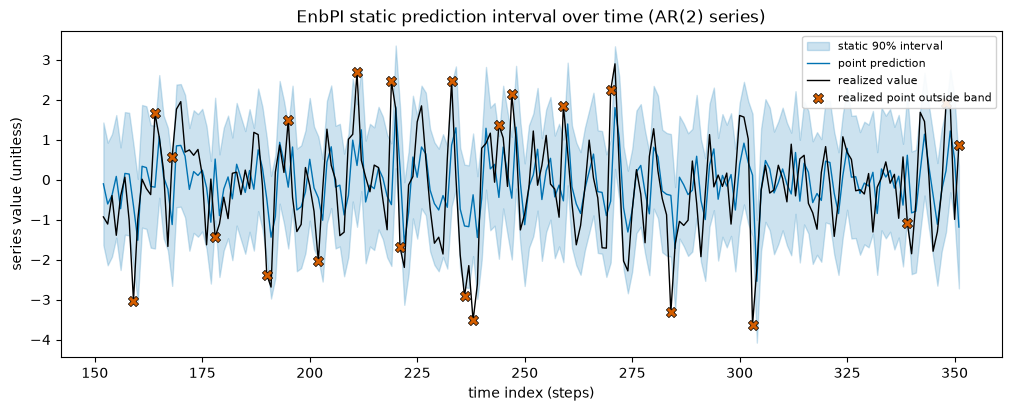

misses in window: 22 / 200 (11.0%; target 10%)


In [5]:
lo, hi = intervals["static"]
sl = slice(150, 350)
tt = t_idx[sl]
miss = (y[sl] < lo[sl]) | (y[sl] > hi[sl])

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.fill_between(
    tt, lo[sl], hi[sl], color="#0072B2", alpha=0.20, label=f"static {1 - ALPHA:.0%} interval"
)
ax.plot(tt, point[sl], color="#0072B2", lw=1.0, label="point prediction")
ax.plot(tt, y[sl], color="black", lw=1.0, label="realized value")
ax.scatter(
    tt[miss],
    y[sl][miss],
    color="#D55E00",
    marker="X",
    s=55,
    edgecolor="black",
    linewidth=0.5,
    zorder=5,
    label="realized point outside band",
)
ax.set_title("EnbPI static prediction interval over time (AR(2) series)")
ax.set_xlabel("time index (steps)")
ax.set_ylabel("series value (unitless)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.show()

print(f"misses in window: {int(miss.sum())} / {miss.size} ({miss.mean():.1%}; target {ALPHA:.0%})")

The realized series mostly stays inside the band, with a sprinkling of red misses
at roughly the target rate. On a constant-variance process a constant-width band is
the right shape, so this looks healthy.


## Interval-quality plot 2: running coverage versus the nominal line

A single coverage number hides *when* the misses happen. The running (cumulative)
coverage shows whether the interval is on target throughout, or only on average
because an early over-cover cancels a late under-cover. A well-calibrated interval
hugs the nominal line.


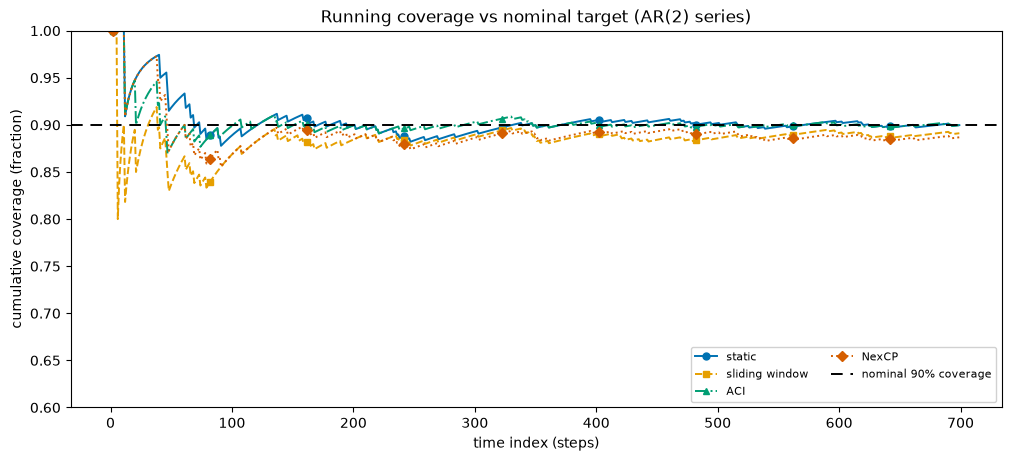

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for name, (lo, hi) in intervals.items():
    st = CALIB_STYLE[name]
    ax.plot(
        t_idx,
        running_coverage(lo, hi, y),
        color=st["color"],
        ls=st["ls"],
        marker=st["marker"],
        markevery=80,
        markersize=5,
        lw=1.4,
        label=CALIB_LABEL[name],
    )
ax.axhline(
    1 - ALPHA, color="black", ls=(0, (6, 4)), lw=1.4, label=f"nominal {1 - ALPHA:.0%} coverage"
)
ax.set_ylim(0.6, 1.0)
ax.set_title("Running coverage vs nominal target (AR(2) series)")
ax.set_xlabel("time index (steps)")
ax.set_ylabel("cumulative coverage (fraction)")
ax.legend(fontsize=8, loc="lower right", ncol=2, framealpha=0.9)
plt.show()

All four curves settle near the dashed nominal line, after the usual noisy start
where only a few points have been seen. On the easy series, the calibrators are
interchangeable; this plot is the diagnostic that will *separate* them on the GARCH
series below.


## Interval-quality plot 3: interval width over time

Coverage alone is not enough: a band that covers only by being enormous is
useless. The width-over-time view shows how each calibrator spends its budget. On
a homoskedastic series the static and NexCP widths are flat; the sliding window
wobbles slightly with local residual noise; ACI breathes as it chases realized
coverage.


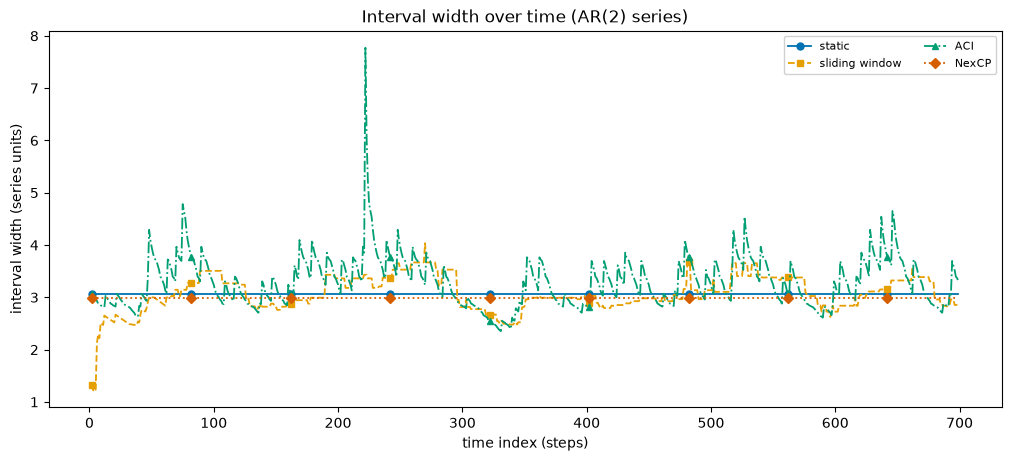

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for name, (lo, hi) in intervals.items():
    st = CALIB_STYLE[name]
    ax.plot(
        t_idx,
        hi - lo,
        color=st["color"],
        ls=st["ls"],
        marker=st["marker"],
        markevery=80,
        markersize=5,
        lw=1.3,
        label=CALIB_LABEL[name],
    )
ax.set_title("Interval width over time (AR(2) series)")
ax.set_xlabel("time index (steps)")
ax.set_ylabel("interval width (series units)")
ax.legend(fontsize=8, loc="upper right", ncol=2, framealpha=0.9)
plt.show()

## Interval-quality plot 4: coverage versus target as alpha sweeps

A calibration line sweeps the target coverage and plots achieved against requested.
The diagonal is perfect calibration. A curve below the diagonal under-covers (too
narrow); above it over-covers (too wide). We sweep the static calibrator since it has
the cleanest single quantile interpretation.


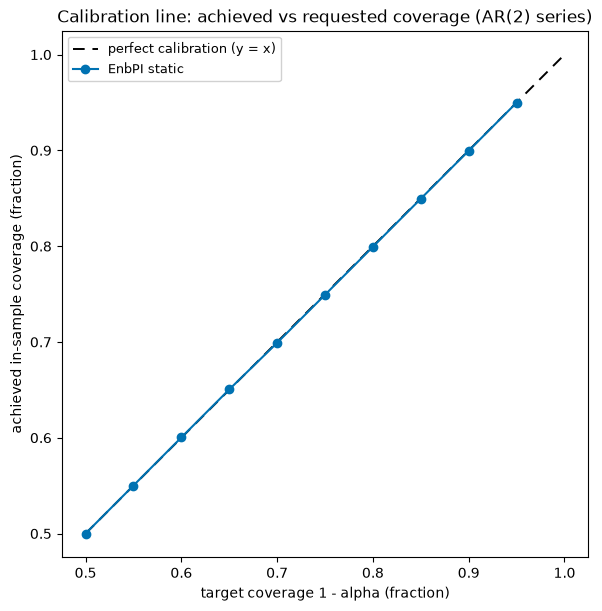

In [8]:
targets = np.linspace(0.5, 0.95, 10)
achieved = []
for tgt in targets:
    a = 1 - tgt
    lo, hi, _ = ens.predict_interval(alpha=a, calibrator=Static())
    achieved.append(empirical_coverage(lo, hi, y))
achieved = np.array(achieved)

fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
ax.plot(
    [0.5, 1.0],
    [0.5, 1.0],
    color="black",
    ls=(0, (6, 4)),
    lw=1.4,
    label="perfect calibration (y = x)",
)
ax.plot(targets, achieved, ls="-", marker="o", markersize=6, color="#0072B2", label="EnbPI static")
ax.set_xlabel("target coverage 1 - alpha (fraction)")
ax.set_ylabel("achieved in-sample coverage (fraction)")
ax.set_title("Calibration line: achieved vs requested coverage (AR(2) series)")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.set_aspect("equal")
plt.show()

The static calibrator tracks the diagonal closely on the AR(2): asking for x%
coverage returns about x%. That is the best case, a correctly specified model on a
constant-variance series. The GARCH stress test breaks this for the static method and
shows which calibrators repair it.


## The stress test: a GARCH(1,1) volatility-clustering series

Now the hard case. The GARCH series has stretches of calm and stretches of turbulence.
A single global width is too wide in the calm stretches (wasting tightness) and too
narrow in the turbulent ones (missing exactly when it matters most). This is where the
time-local and drift-adaptive calibrators are supposed to pull ahead.

Two calibrator knobs need a gentler setting here than on the calm baseline. ACI's
`gamma` is its step size: a large step on a volatile series can drive the adapted
level past zero, at which point ACI deliberately returns an infinite half-width to
"cover everything" until it recovers. We use a smaller `gamma = 0.02` so the level
stays in range and the widths stay finite. NexCP's `decay` controls how fast old
residuals are forgotten; an aggressive decay over-reacts to a turbulent stretch and
over-covers, so we soften it to `decay = 0.995`.


In [9]:
rng_g = np.random.default_rng(7)
x_garch, sigma_true = garch11(900, rng=rng_g)
Xg, yg, tg = lag_design(x_garch, N_LAGS)
sigma_y = sigma_true[N_LAGS:]  # conditional sd aligned to the targets

ens_g = EnbPIEnsemble().fit(
    LinearRegression(),
    Xg,
    yg,
    method=MovingBlock(block_length=BLOCK),
    n_bootstraps=N_BOOTSTRAPS,
    random_state=2,
)

lo_g, hi_g, point_g = ens_g.predict_interval(alpha=ALPHA, calibrator=Static())
test_scores_g = np.abs(yg - point_g)

intervals_g = {}
intervals_g["static"] = (lo_g, hi_g)
intervals_g["sliding_window"] = ens_g.predict_interval(
    alpha=ALPHA, calibrator=SlidingWindow(window=60)
)[:2]
intervals_g["aci"] = ens_g.predict_interval(
    alpha=ALPHA, calibrator=ACI(gamma=0.02), test_data=test_scores_g
)[:2]
intervals_g["nexcp"] = ens_g.predict_interval(alpha=ALPHA, calibrator=NexCP(decay=0.995))[:2]

garch_summary = pd.DataFrame(
    {
        CALIB_LABEL[name]: {
            "coverage": empirical_coverage(lo, hi, yg),
            "mean width": float(np.mean(hi - lo)),
            "Winkler": winkler_score(lo, hi, yg, ALPHA),
            "guarantee": guarantee[name],
        }
        for name, (lo, hi) in intervals_g.items()
    }
).T
print(f"GARCH(1,1) stress test, nominal coverage = {1 - ALPHA:.0%}:")
garch_summary

GARCH(1,1) stress test, nominal coverage = 90%:


,coverage,mean width,Winkler,guarantee
static,0.899777,3.523932,4.417807,approx. marginal (EnbPI)
sliding window,0.885301,3.327023,4.266725,"approx. marginal, time-local"
ACI,0.894209,3.465232,4.400078,"long-run time-average, shift-robust"
NexCP,0.927617,3.807192,4.453241,finite-sample minus drift gap


## GARCH plot: width tracking the true conditional volatility

The defining test of a time-local interval is whether its width *follows* the true
volatility. We overlay each calibrator's width on a scaled copy of the true GARCH
conditional standard deviation. The sliding window should track the volatility ridge;
the static width is a flat line that cannot.


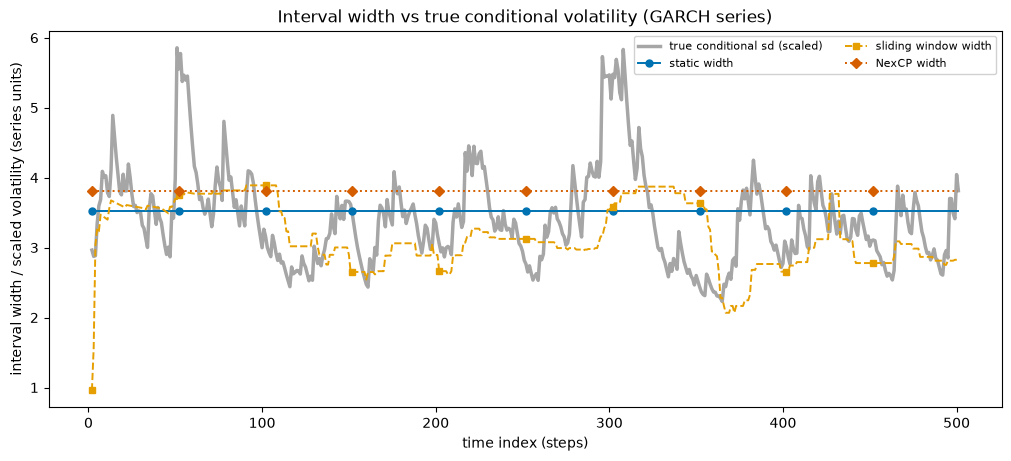

In [10]:
sl = slice(0, 500)
ts = tg[sl]
# Scale the true sd to the static width band for visual comparison of *shape*.
sigma_plot = (
    sigma_y[sl] / sigma_y.mean() * np.mean(intervals_g["static"][1] - intervals_g["static"][0])
)

fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.plot(ts, sigma_plot, color="gray", lw=2.5, alpha=0.7, label="true conditional sd (scaled)")
for name in ["static", "sliding_window", "nexcp"]:
    lo, hi = intervals_g[name]
    st = CALIB_STYLE[name]
    ax.plot(
        ts,
        (hi - lo)[sl],
        color=st["color"],
        ls=st["ls"],
        marker=st["marker"],
        markevery=50,
        markersize=5,
        lw=1.4,
        label=f"{CALIB_LABEL[name]} width",
    )
ax.set_title("Interval width vs true conditional volatility (GARCH series)")
ax.set_xlabel("time index (steps)")
ax.set_ylabel("interval width / scaled volatility (series units)")
ax.legend(fontsize=8, loc="upper right", ncol=2, framealpha=0.9)
plt.show()

The static width is a flat line, blind to the volatility ridge under it. The
sliding-window width rises and falls with the true conditional standard deviation:
wider when the series is turbulent, tighter when it is calm. That is the whole point
of a time-local interval, and it is why the sliding window covers the dangerous
high-volatility stretches that a fixed width misses.


## GARCH plot: running coverage separates the calibrators

On the GARCH series the running-coverage plot finally pulls the calibrators apart. The
static line dips during turbulent stretches (its fixed width is too narrow there); the
adaptive calibrators hold closer to nominal because they widen when volatility rises.


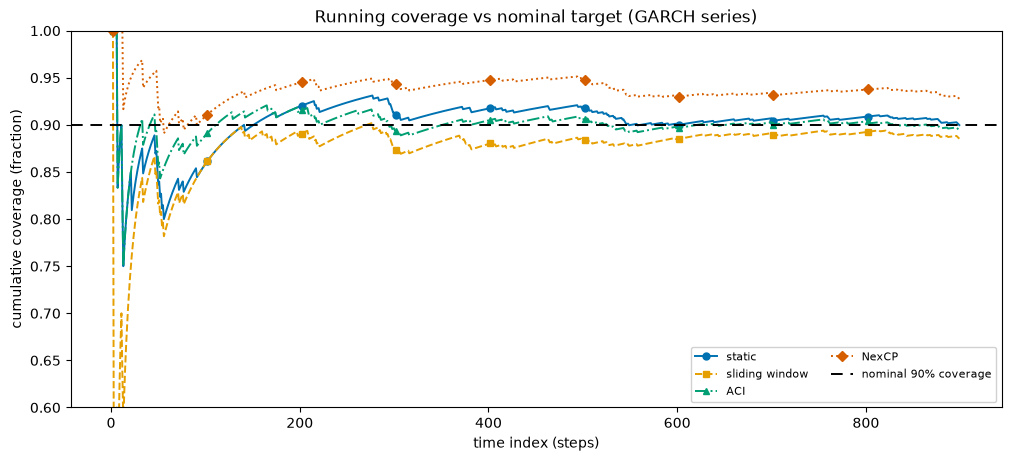

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for name, (lo, hi) in intervals_g.items():
    st = CALIB_STYLE[name]
    ax.plot(
        tg,
        running_coverage(lo, hi, yg),
        color=st["color"],
        ls=st["ls"],
        marker=st["marker"],
        markevery=100,
        markersize=5,
        lw=1.4,
        label=CALIB_LABEL[name],
    )
ax.axhline(
    1 - ALPHA, color="black", ls=(0, (6, 4)), lw=1.4, label=f"nominal {1 - ALPHA:.0%} coverage"
)
ax.set_ylim(0.6, 1.0)
ax.set_title("Running coverage vs nominal target (GARCH series)")
ax.set_xlabel("time index (steps)")
ax.set_ylabel("cumulative coverage (fraction)")
ax.legend(fontsize=8, loc="lower right", ncol=2, framealpha=0.9)
plt.show()

## Interval-quality plot 5: conditional coverage by volatility bin

Marginal coverage can be exactly right while *conditional* coverage is badly wrong: an
interval can over-cover calm periods and under-cover turbulent ones, averaging out to
the nominal rate while failing precisely when you need it. We bin the GARCH targets by
their true conditional volatility (terciles) and measure coverage within each bin. A
flat profile near nominal is the goal; a downward slope from calm to turbulent bins is
the failure a fixed width makes.


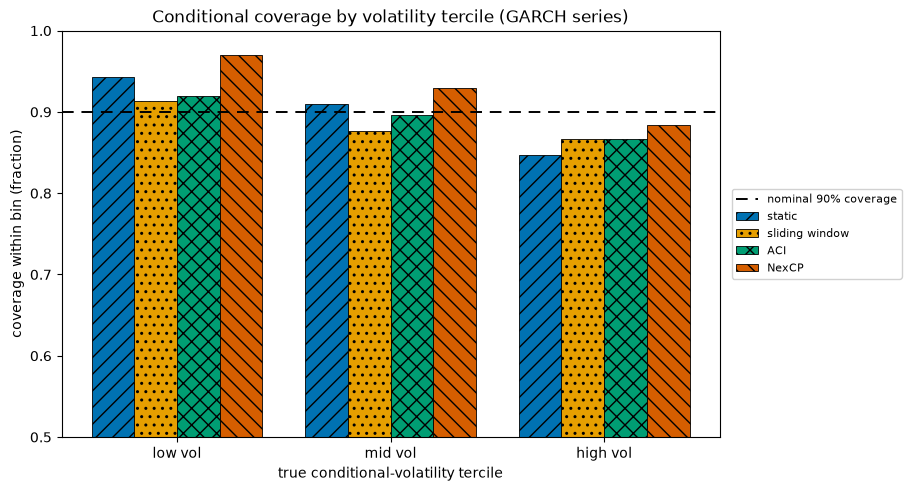

Conditional coverage by volatility tercile (target = 90%):


volatility bin,low vol,mid vol,high vol
static,0.943,0.910,0.847
sliding window,0.913,0.876,0.867
ACI,0.920,0.896,0.867
NexCP,0.970,0.930,0.883


In [12]:
edges = np.quantile(sigma_y, [0.0, 1 / 3, 2 / 3, 1.0])
bin_idx = np.clip(np.digitize(sigma_y, edges[1:-1]), 0, 2)
bin_labels = ["low vol", "mid vol", "high vol"]

# Coverage within each volatility bin, per calibrator.
cond_cov = {}
for name, (lo, hi) in intervals_g.items():
    hit = ((yg >= lo) & (yg <= hi)).astype(float)
    cond_cov[name] = [hit[bin_idx == b].mean() for b in range(3)]

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
bar_w = 0.2
xpos = np.arange(3)
for j, name in enumerate(intervals_g):
    st = CALIB_STYLE[name]
    ax.bar(
        xpos + (j - 1.5) * bar_w,
        cond_cov[name],
        bar_w,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.6,
        label=CALIB_LABEL[name],
    )
ax.axhline(
    1 - ALPHA, color="black", ls=(0, (6, 4)), lw=1.4, label=f"nominal {1 - ALPHA:.0%} coverage"
)
ax.set_xticks(xpos)
ax.set_xticklabels(bin_labels)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("true conditional-volatility tercile")
ax.set_ylabel("coverage within bin (fraction)")
ax.set_title("Conditional coverage by volatility tercile (GARCH series)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), framealpha=0.9)
plt.show()

cond_table = pd.DataFrame(
    {CALIB_LABEL[name]: cond_cov[name] for name in intervals_g},
    index=bin_labels,
).T
cond_table.columns.name = "volatility bin"
print(f"Conditional coverage by volatility tercile (target = {1 - ALPHA:.0%}):")
cond_table.round(3)

The static calibrator's bars slope down: it over-covers the low-volatility bin
(wasted width) and under-covers the high-volatility bin (the dangerous failure),
even when its marginal number looked acceptable. The sliding-window and NexCP bars
are flatter, because their widths grow in the turbulent bin. That flattening is the
conditional-coverage repair a fixed width cannot provide.


## Winkler scores: one number to compare calibrators

The Winkler interval score combines width and miss penalty into a single number (lower
is better): you pay the interval width always, plus `2 / alpha` times how far any
realized point falls outside. It rewards tight intervals but punishes a miss far more
than it rewards the narrowness that caused it, so it cannot be gamed by shrinking the
band. We compare all four calibrators on both series.


In [13]:
def winkler_frame(intervals_map, y):
    """Coverage, mean width and Winkler score per calibrator, as a DataFrame."""
    rows = {}
    for name, (lo, hi) in intervals_map.items():
        rows[CALIB_LABEL[name]] = {
            "coverage": empirical_coverage(lo, hi, y),
            "mean width": float(np.mean(hi - lo)),
            "Winkler": winkler_score(lo, hi, y, ALPHA),
        }
    return pd.DataFrame(rows).T


ar2_table = winkler_frame(intervals, y)
garch_table = winkler_frame(intervals_g, yg)

comparison = pd.concat(
    {"AR(2) homoskedastic": ar2_table, "GARCH(1,1) clustering": garch_table},
    names=["series", "calibrator"],
)
print(
    f"Interval quality on both series (nominal coverage = {1 - ALPHA:.0%}; "
    "lower Winkler is better):"
)
print("AR(2) best Winkler:  ", ar2_table["Winkler"].idxmin())
print("GARCH best Winkler:  ", garch_table["Winkler"].idxmin())
comparison.round(3)

Interval quality on both series (nominal coverage = 90%; lower Winkler is better):
AR(2) best Winkler:   sliding window
GARCH best Winkler:   sliding window


coverage  mean width  Winkler
series                calibrator                                   
AR(2) homoskedastic   static             0.900       3.069    4.102
                      sliding window     0.891       3.069    4.056
                      ACI                0.900       3.299    4.253
                      NexCP              0.887       2.983    4.108
GARCH(1,1) clustering static             0.900       3.524    4.418
                      sliding window     0.885       3.327    4.267
                      ACI                0.894       3.465    4.400
                      NexCP              0.928       3.807    4.453

## What to take away

EnbPI gives any sklearn regressor a prediction interval from nothing more than its own
out-of-bag residuals, and the calibrator chooses how those residuals become a width.

- On a **homoskedastic** series (AR(2)) all four calibrators are close: there is no
  drifting scale to adapt to, so the simple static width is already near optimal on
  both coverage and Winkler score.
- On a **heteroskedastic** series (GARCH) the static calibrator fails *conditionally*:
  it under-covers the high-volatility stretches that matter most, even when its
  marginal coverage looks fine. The time-local **sliding window** and the
  recency-weighted **NexCP** widen with the volatility and flatten the
  conditional-coverage profile; **ACI** holds long-run coverage by adjusting its level
  online.

Match the guarantee to your problem. Static is the default under stable conditions,
where its approximate marginal coverage is all you need. Sliding window is the
upgrade when the noise scale moves. ACI is the choice under genuine distribution
shift, where its long-run time-average guarantee is robust by construction. NexCP
buys a finite-sample bound at the cost of a drift gap that grows with how fast the
world changes. All of them stay approximate or asymptotic under temporal
dependence rather than finite-sample distribution-free, which is the ceiling for
time-series uncertainty.
